# Proyecto Final — Fase 1  
## Análisis exploratorio, calidad de datos, estacionariedad, autocorrelación y modelos baseline para casos de dengue

**Maestría en Inteligencia Artificial y Ciencias de Datos — Análisis y Pronósticos de Series de Tiempo**

Este notebook desarrolla la **Fase 1: Fundamentos y Línea Base** usando el dataset `datos_dengue_202604282143.csv`. La estructura sigue la metodología del taller base: configuración reproducible, calidad de datos, detección de outliers, análisis de autocorrelación, estacionariedad y modelos baseline.

### Decisión metodológica principal
El archivo contiene registros individuales con fecha de notificación (`fec_not`) y semana epidemiológica (`semana`). Para convertirlo en serie temporal, se agrega el número de registros por semana. La variable principal será:

\[
y_t = \text{número de casos notificados de dengue en la semana } t
\]

Se usa frecuencia **semanal** porque dengue es una enfermedad con dinámica epidemiológica más lenta que el ruido diario, y porque el propio dataset incluye una variable de semana. Esto reduce variabilidad administrativa diaria y permite estudiar patrones estacionales/cíclicos.

## 1. Configuración del entorno y reproducibilidad

In [3]:
# ============================================================
# 1. CONFIGURACIÓN GENERAL
# ============================================================
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from scipy.signal import periodogram

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = Path('datos_dengue_202604282143.csv')
if not DATA_PATH.exists():
    # Ruta alternativa cuando se ejecuta desde /mnt/data
    DATA_PATH = Path('/mnt/data/datos_dengue_202604282143.csv')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Conclusión de la sección 1
La configuración inicial deja el notebook preparado para un análisis reproducible: se fijan librerías, formato de salida, estilo gráfico y parámetros globales. Esta sección no genera hallazgos epidemiológicos por sí misma, pero sí garantiza que las tablas, pruebas estadísticas y gráficos posteriores se produzcan bajo un mismo entorno de trabajo, reduciendo diferencias por formato o ejecución.


## 2. Carga, selección y caracterización del dataset

**Contexto:** El dengue es una enfermedad transmitida por mosquitos. Sus casos suelen mostrar dependencia temporal por factores ambientales, acumulación de susceptibles, circulación viral, campañas de control y cambios de reporte. Por eso es razonable tratar la cantidad de casos notificados como una serie temporal de conteos.

**Justificación de selección:** el dataset cumple las condiciones de la fase 1: es real, tiene fecha, permite definir frecuencia semanal y se puede trabajar con una variable principal agregada. Además, por tratarse de salud pública, es un caso relevante para pronóstico operacional.

In [4]:
# ============================================================
# 2. CARGA Y VALIDACIÓN INICIAL
# ============================================================
def cargar_datos(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower() for c in df.columns]
    df['fec_not'] = pd.to_datetime(df['fec_not'], errors='coerce')
    return df

raw = cargar_datos(DATA_PATH)
print('Dimensiones del archivo original:', raw.shape)
display(raw.head())
display(raw.info())

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/datos_dengue_202604282143.csv'

In [ ]:
# Resumen de calidad de los campos originales
quality_raw = pd.DataFrame({
    'tipo': raw.dtypes.astype(str),
    'n_faltantes': raw.isna().sum(),
    'pct_faltantes': raw.isna().mean() * 100,
    'n_unicos': raw.nunique(dropna=True)
})

display(quality_raw)

print('Rango de fechas:', raw['fec_not'].min(), '→', raw['fec_not'].max())
print('Rango semana reportada:', raw['semana'].min(), '→', raw['semana'].max())
print('Registros duplicados exactos:', raw.duplicated().sum())

,tipo,n_faltantes,pct_faltantes,n_unicos
fec_not,datetime64[ns],0,0.0000,4666
semana,int64,0,0.0000,53


Rango de fechas: 2010-01-03 00:00:00 → 2024-03-29 00:00:00
Rango semana reportada: 1 → 53
Registros duplicados exactos: 50050


### Conclusión de la sección 2
El dataset contiene registros individuales de dengue entre el 3 de enero de 2010 y el 29 de marzo de 2024. Los campos principales no presentan valores faltantes: `fec_not` tiene tipo fecha y `semana` toma valores entre 1 y 53, lo cual es consistente con semanas epidemiológicas. Los 50,050 duplicados exactos no se interpretan como errores, porque varias filas pueden compartir fecha y semana al representar casos individuales notificados el mismo día.


### Construcción de la serie semanal

Hay dos formas posibles de agregar: por `año + semana` o por re-muestreo de la fecha de notificación. En este notebook se usa `resample('W-SUN')`, que genera una secuencia semanal regular terminada en domingo. Esto facilita descomposición, ACF/PACF, validación temporal y modelos baseline.

**Nota:** los duplicados exactos no se eliminan, porque cada fila representa un caso notificado; varios registros con la misma fecha son esperados.

In [ ]:
# ============================================================
# 3. CONSTRUCCIÓN DE LA SERIE TEMPORAL SEMANAL
# ============================================================
def construir_serie_semanal(df: pd.DataFrame, freq: str = 'W-SUN') -> pd.Series:
    serie = (
        df.dropna(subset=['fec_not'])
          .set_index('fec_not')
          .sort_index()
          .resample(freq)
          .size()
          .rename('casos')
    )
    # Garantiza frecuencia regular explícita
    serie = serie.asfreq(freq, fill_value=0)
    return serie

serie = construir_serie_semanal(raw)
weekly = serie.to_frame()
weekly['anio'] = weekly.index.year
weekly['mes'] = weekly.index.month
weekly['semana_iso'] = weekly.index.isocalendar().week.astype(int)
weekly['trimestre'] = weekly.index.quarter

print('Frecuencia inferida:', pd.infer_freq(serie.index))
print('Número de semanas:', len(serie))
print('Total de casos agregados:', int(serie.sum()))
print('Semanas con cero casos:', int((serie == 0).sum()))
display(weekly.head())
display(weekly.tail())

Frecuencia inferida: W-SUN
Número de semanas: 744
Total de casos agregados: 61933
Semanas con cero casos: 3


,casos,anio,mes,semana_iso,trimestre
fec_not,,,,,
2010-01-03,12,2010,1,53,1
2010-01-10,142,2010,1,1,1
2010-01-17,210,2010,1,2,1
2010-01-24,253,2010,1,3,1
2010-01-31,345,2010,1,4,1


,casos,anio,mes,semana_iso,trimestre
fec_not,,,,,
2024-03-03,0,2024,3,9,1
2024-03-10,5,2024,3,10,1
2024-03-17,0,2024,3,11,1
2024-03-24,0,2024,3,12,1
2024-03-31,1,2024,3,13,1


### Conclusión de la construcción semanal
La agregación semanal produce una serie regular `W-SUN` de 744 observaciones, sin saltos de calendario, con 61,933 casos acumulados. Solo aparecen 3 semanas con cero casos, por lo que la serie es suficientemente continua para aplicar descomposición, autocorrelación, pruebas de estacionariedad y validación temporal. La caída a valores cercanos a cero en las últimas semanas de 2024 debe leerse con cautela porque el año está incompleto.


## 3. Análisis de calidad de datos

La calidad se evalúa en dos niveles:

1. **Nivel registro:** fechas inválidas, semana fuera de rango y registros exactos repetidos.
2. **Nivel serie:** continuidad temporal, semanas sin casos y valores extremos.

En series epidemiológicas, los picos no deben tratarse automáticamente como errores, porque pueden representar brotes reales. Por eso se identifican outliers, pero no se eliminan de la serie principal salvo evidencia de error de captura.

In [ ]:
# ============================================================
# 4. CALIDAD DE DATOS A NIVEL SERIE
# ============================================================
def resumen_calidad_serie(s: pd.Series) -> pd.DataFrame:
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq=s.index.freq)
    faltantes_calendario = full_idx.difference(s.index)
    return pd.DataFrame({
        'metrica': [
            'fecha_inicio', 'fecha_fin', 'n_observaciones', 'frecuencia',
            'semanas_faltantes_calendario', 'semanas_con_cero_casos',
            'casos_totales', 'casos_min', 'casos_max'
        ],
        'valor': [
            s.index.min(), s.index.max(), len(s), pd.infer_freq(s.index),
            len(faltantes_calendario), int((s == 0).sum()),
            int(s.sum()), int(s.min()), int(s.max())
        ]
    })

quality_series = resumen_calidad_serie(serie)
display(quality_series)

,metrica,valor
0,fecha_inicio,2010-01-03 00:00:00
1,fecha_fin,2024-03-31 00:00:00
2,n_observaciones,744
3,frecuencia,W-SUN
4,semanas_faltantes_calendario,0
5,semanas_con_cero_casos,3
6,casos_totales,61933
7,casos_min,0
8,casos_max,573


### Conclusión de la sección 3
A nivel de serie temporal, la calidad es adecuada para modelado: hay frecuencia semanal regular, cero semanas faltantes en el calendario y el total agregado coincide con los 61,933 registros originales. La presencia de semanas con cero casos no invalida la serie; en conteos epidemiológicos puede corresponder a ausencia de notificación o a periodos de baja incidencia.


In [ ]:
# Detección de outliers con IQR y Z-score robusto (MAD)
def detectar_outliers_iqr(s: pd.Series, factor: float = 1.5) -> pd.DataFrame:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf = q1 - factor * iqr
    lim_sup = q3 + factor * iqr
    out = pd.DataFrame({'casos': s})
    out['outlier_iqr'] = (s < lim_inf) | (s > lim_sup)
    out['lim_inf_iqr'] = lim_inf
    out['lim_sup_iqr'] = lim_sup
    return out

def detectar_outliers_mad(s: pd.Series, threshold: float = 3.5) -> pd.DataFrame:
    mediana = np.median(s)
    mad = np.median(np.abs(s - mediana))
    z_robusto = 0.6745 * (s - mediana) / mad if mad != 0 else pd.Series(np.nan, index=s.index)
    out = pd.DataFrame({'casos': s, 'z_robusto': z_robusto})
    out['outlier_mad'] = np.abs(z_robusto) > threshold
    return out

out_iqr = detectar_outliers_iqr(serie)
out_mad = detectar_outliers_mad(serie)
outliers = out_iqr.join(out_mad[['z_robusto', 'outlier_mad']])

print('Outliers IQR:', int(outliers['outlier_iqr'].sum()))
print('Outliers MAD:', int(outliers['outlier_mad'].sum()))
display(outliers.query('outlier_iqr or outlier_mad').sort_values('casos', ascending=False).head(15))

Outliers IQR: 57
Outliers MAD: 57


,casos,outlier_iqr,lim_inf_iqr,lim_sup_iqr,z_robusto,outlier_mad
fec_not,,,,,,
2010-02-21,573,True,-115.7500,238.2500,9.5159,True
2010-02-28,543,True,-115.7500,238.2500,8.9690,True
2023-12-31,537,True,-115.7500,238.2500,8.8596,True
2010-02-14,504,True,-115.7500,238.2500,8.2581,True
2010-03-07,475,True,-115.7500,238.2500,7.7294,True
2023-12-24,466,True,-115.7500,238.2500,7.5653,True
2010-03-14,451,True,-115.7500,238.2500,7.2919,True
2023-12-17,442,True,-115.7500,238.2500,7.1278,True
2010-03-21,439,True,-115.7500,238.2500,7.0731,True


### Conclusión sobre valores extremos
Los métodos IQR y MAD identifican 57 semanas extremas, con picos destacados en 2010, 2020 y 2023. Estos valores son epidemiológicamente plausibles porque reflejan brotes o aumentos intensos de transmisión, no simples errores estadísticos. Por esa razón se mantienen en la serie principal: eliminarlos haría que los modelos posteriores aprendan una dinámica artificialmente suavizada y menos útil para vigilancia.


**Decisión de tratamiento de outliers:** no se eliminan ni winsorizan para el análisis principal, porque los valores extremos corresponden precisamente a brotes o semanas epidemiológicamente relevantes. Para modelado baseline, mantenerlos permite evaluar qué tan difícil es anticipar aumentos bruscos con modelos simples. Se puede construir una versión winsorizada solo como análisis de sensibilidad.

## 4. Estadísticas descriptivas y segmentación temporal

In [ ]:
# ============================================================
# 5. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================
def estadisticas_descriptivas(s: pd.Series) -> pd.DataFrame:
    return pd.DataFrame({
        'media': [s.mean()],
        'mediana': [s.median()],
        'varianza': [s.var()],
        'desviacion': [s.std()],
        'coef_variacion': [s.std() / s.mean() if s.mean() != 0 else np.nan],
        'asimetria': [stats.skew(s, bias=False)],
        'curtosis_exceso': [stats.kurtosis(s, fisher=True, bias=False)],
        'min': [s.min()],
        'q1': [s.quantile(0.25)],
        'q3': [s.quantile(0.75)],
        'max': [s.max()]
    }).T.rename(columns={0: 'valor'})

stats_serie = estadisticas_descriptivas(serie)
display(stats_serie)

annual = weekly.groupby('anio')['casos'].agg(['sum','mean','median','std','max'])
annual['cv'] = annual['std'] / annual['mean']
display(annual)

,valor
media,83.2433
mediana,51.0000
varianza,"9,473.6298"
desviacion,97.3326
coef_variacion,1.1693
asimetria,2.0645
curtosis_exceso,4.5468
min,0.0000
q1,17.0000
q3,105.5000


,sum,mean,median,std,max,cv
anio,,,,,,
2010,10666,205.1154,170.5000,139.1004,573,0.6782
2011,634,12.1923,10.0000,6.1677,37,0.5059
2012,1107,20.8868,19.0000,7.9896,49,0.3825
2013,8364,160.8462,149.5000,42.3378,255,0.2632
2014,3148,60.5385,59.5000,13.4361,100,0.2219
2015,4325,83.1731,82.5000,20.3785,129,0.2450
2016,7181,138.0962,132.0000,106.9840,365,0.7747
2017,719,13.5660,11.0000,9.9740,44,0.7352
2018,297,5.7115,5.0000,3.2500,16,0.5690


### Conclusión de la sección 4
La serie muestra alta variabilidad: media semanal de 83.24 casos, mediana de 51, desviación estándar de 97.33 y coeficiente de variación de 1.17. La asimetría positiva de 2.06 y la curtosis de 4.55 confirman una distribución con muchos valores bajos o moderados y pocos picos muy altos. Por año, 2010, 2013, 2016, 2020 y 2023 concentran episodios de mayor incidencia, mientras que años como 2018 muestran niveles muy bajos.


In [ ]:
# Visualización interactiva de la serie
fig = px.line(
    weekly, x=weekly.index, y='casos',
    title='Casos semanales de dengue — serie temporal agregada',
    labels={'index': 'Semana', 'casos': 'Casos notificados'}
)
fig.update_layout(template='plotly_white', hovermode='x unified')
fig.show()

In [ ]:
# Distribución y boxplots temporales
fig = make_subplots(rows=1, cols=2, subplot_titles=('Distribución de casos semanales', 'Boxplot por año'))
fig.add_trace(go.Histogram(x=serie, nbinsx=40, name='Casos'), row=1, col=1)
fig.add_trace(go.Box(x=weekly['anio'], y=weekly['casos'], name='Casos por año'), row=1, col=2)
fig.update_layout(template='plotly_white', title='Distribución y dispersión temporal', showlegend=False)
fig.show()

### Análisis de tendencia mediante medias móviles

Se calculan medias móviles de 4, 13, 26 y 52 semanas. La de 4 semanas suaviza ruido de corto plazo; 13 semanas aproxima comportamiento trimestral; 26 semanas captura semestres; 52 semanas representa tendencia anual móvil.

In [ ]:
# ============================================================
# 6. MEDIAS MÓVILES
# ============================================================
ma_df = weekly[['casos']].copy()
for w in [4, 13, 26, 52]:
    ma_df[f'MA_{w}'] = ma_df['casos'].rolling(w, min_periods=max(2, w//3)).mean()

fig = go.Figure()
fig.add_trace(go.Scatter(x=ma_df.index, y=ma_df['casos'], name='Casos', opacity=0.35))
for w in [4, 13, 26, 52]:
    fig.add_trace(go.Scatter(x=ma_df.index, y=ma_df[f'MA_{w}'], name=f'Media móvil {w} semanas'))
fig.update_layout(template='plotly_white', title='Tendencia mediante medias móviles', xaxis_title='Semana', yaxis_title='Casos')
fig.show()

In [ ]:
# Segmentación por semana del año para observar patrón intra-anual
seasonal_profile = weekly.groupby('semana_iso')['casos'].agg(['mean','median','std','count'])
seasonal_profile['cv'] = seasonal_profile['std'] / seasonal_profile['mean']

display(seasonal_profile.head())

fig = px.line(
    seasonal_profile.reset_index(), x='semana_iso', y=['mean','median'],
    title='Perfil promedio y mediano por semana ISO del año',
    labels={'semana_iso': 'Semana ISO', 'value': 'Casos', 'variable': 'Estadístico'}
)
fig.update_layout(template='plotly_white')
fig.show()

,mean,median,std,count,cv
semana_iso,,,,,
1,76.6667,65.0000,63.2802,15,0.8254
2,74.4667,42.0000,72.7293,15,0.9767
3,90.4000,55.0000,96.5725,15,1.0683
4,93.6667,41.0000,103.2892,15,1.1027
5,116.8667,51.0000,142.0070,15,1.2151


### Conclusión sobre tendencia y segmentación temporal
Las medias móviles permiten separar el ruido semanal de los cambios de nivel más persistentes. La serie no se comporta como un proceso estable alrededor de una media fija: alterna periodos de baja incidencia con ciclos epidémicos prolongados. El perfil por semana del año sugiere variación intra-anual, pero con coeficientes de variación altos; esto indica que el calendario anual ayuda, aunque no explica por sí solo la magnitud de los brotes.


## 5. Determinación del período estacional

Se combinan dos criterios:

- **Criterio de dominio:** en una serie semanal, una estacionalidad anual equivale aproximadamente a 52 semanas.
- **Criterio estadístico:** periodograma y autocorrelación para buscar ciclos dominantes.

En enfermedades como dengue, puede existir estacionalidad anual asociada al clima, pero también ciclos epidémicos multi-anuales. Por eso no se fuerza una única lectura: se reportan ambos patrones.

In [ ]:
# ============================================================
# 7. AUTODETECCIÓN DE PERIODOS CANDIDATOS
# ============================================================
def detectar_periodos_periodograma(s: pd.Series, min_period: int = 4, max_period: int = 260, top_n: int = 10) -> pd.DataFrame:
    y = s.values - np.mean(s.values)
    freq, power = periodogram(y)
    mask = freq > 0
    periods = 1 / freq[mask]
    power = power[mask]
    cand = pd.DataFrame({'periodo_semanas': periods, 'potencia': power})
    cand = cand[(cand['periodo_semanas'] >= min_period) & (cand['periodo_semanas'] <= max_period)]
    cand['periodo_redondeado'] = cand['periodo_semanas'].round().astype(int)
    return cand.sort_values('potencia', ascending=False).head(top_n)

periodos_candidatos = detectar_periodos_periodograma(serie)
display(periodos_candidatos)

# Se adopta 52 como periodo estacional operativo para esta fase, por frecuencia semanal y comparabilidad futura con SARIMA/SARIMAX.
SEASONAL_PERIOD = 52
print('Periodo estacional seleccionado:', SEASONAL_PERIOD, 'semanas')

,periodo_semanas,potencia,periodo_redondeado
3,186.0000,"1,622,710.9048",186
2,248.0000,"870,449.9837",248
6,106.2857,"424,542.8660",106
4,148.8000,"319,055.1337",149
14,49.6000,"248,209.4879",50
16,43.7647,"205,667.2226",44
10,67.6364,"193,725.5221",68
18,39.1579,"184,411.1832",39
9,74.4000,"166,975.2356",74
11,62.0000,"139,425.1726",62


Periodo estacional seleccionado: 52 semanas


### Conclusión de la sección 5
El periodograma resalta ciclos de largo plazo, especialmente alrededor de 186 y 248 semanas, lo que sugiere dinámica multi-anual de brotes. Aun así, se selecciona 52 semanas como período estacional operativo porque la frecuencia semanal permite una lectura anual natural y porque este período es útil para descomposición y modelos baseline estacionales. La interpretación más razonable es combinar ambas ideas: estacionalidad anual débil o moderada más ciclos epidémicos de varios años.


## 6. Descomposición estacional avanzada

Se comparan dos enfoques:

1. **Aditivo en escala original:** asume que la estacionalidad tiene amplitud aproximadamente constante.
2. **Aditivo sobre `log1p(casos)`:** representa una lectura tipo multiplicativa, porque estabiliza varianza y permite trabajar con ceros.

La descomposición multiplicativa pura no es ideal con ceros; por eso se usa `log1p`, que conserva interpretabilidad para conteos epidemiológicos.

In [ ]:
# ============================================================
# 8. DESCOMPOSICIÓN Y FUERZA DE COMPONENTES
# ============================================================
def fuerza_componentes(resultado) -> dict:
    # Mide fuerza de tendencia y estacionalidad usando criterio de Hyndman.
    # Valores cercanos a 1 indican componente fuerte; cercanos a 0 indican componente débil.
    resid = resultado.resid.dropna()
    idx = resid.index
    trend = resultado.trend.loc[idx]
    seasonal = resultado.seasonal.loc[idx]
    resid = resultado.resid.loc[idx]
    fuerza_tendencia = max(0, 1 - np.nanvar(resid) / np.nanvar(trend + resid))
    fuerza_estacional = max(0, 1 - np.nanvar(resid) / np.nanvar(seasonal + resid))
    ruido = np.nanvar(resid)
    return {
        'fuerza_tendencia': fuerza_tendencia,
        'fuerza_estacional': fuerza_estacional,
        'varianza_residual': ruido,
        'std_residual': np.nanstd(resid)
    }

def descomponer(s: pd.Series, period: int, transformacion: str = 'original'):
    if transformacion == 'original':
        x = s.copy()
    elif transformacion == 'log1p':
        x = np.log1p(s)
    else:
        raise ValueError('transformacion debe ser original o log1p')
    return seasonal_decompose(x, model='additive', period=period, extrapolate_trend='freq')

decomp_original = descomponer(serie, SEASONAL_PERIOD, 'original')
decomp_log = descomponer(serie, SEASONAL_PERIOD, 'log1p')

strengths = pd.DataFrame({
    'aditivo_original': fuerza_componentes(decomp_original),
    'aditivo_log1p_equiv_multiplicativo': fuerza_componentes(decomp_log)
}).T

display(strengths)

,fuerza_tendencia,fuerza_estacional,varianza_residual,std_residual
aditivo_original,0.5384,0.0333,"4,263.9620",65.2990
aditivo_log1p_equiv_multiplicativo,0.6746,0.0282,0.4870,0.6978


### Conclusión de la sección 6
La descomposición muestra que la tendencia explica más estructura que la estacionalidad anual: la fuerza de tendencia es 0.5384 en escala original y 0.6746 en `log1p`, mientras que la fuerza estacional es baja, cercana a 0.03. Esto significa que los cambios de nivel entre brotes y periodos tranquilos dominan la serie. La transformación `log1p` reduce el impacto de picos extremos y ofrece una lectura más estable para modelar conteos con ceros.


In [ ]:
# Visualización comparativa de componentes
fig = make_subplots(rows=4, cols=2, shared_xaxes=True,
                    subplot_titles=(
                        'Original - observado', 'Log1p - observado',
                        'Original - tendencia', 'Log1p - tendencia',
                        'Original - estacional', 'Log1p - estacional',
                        'Original - residuo', 'Log1p - residuo'
                    ))

components = [('observed','observed'), ('trend','trend'), ('seasonal','seasonal'), ('resid','resid')]
for r, (attr, label) in enumerate(components, start=1):
    fig.add_trace(go.Scatter(x=serie.index, y=getattr(decomp_original, attr), name=f'Original {label}'), row=r, col=1)
    fig.add_trace(go.Scatter(x=serie.index, y=getattr(decomp_log, attr), name=f'Log1p {label}'), row=r, col=2)
fig.update_layout(height=900, template='plotly_white', title='Descomposición estacional comparativa')
fig.show()

In [ ]:
# Análisis de residuos de la descomposición
resid_compare = pd.DataFrame({
    'resid_original': decomp_original.resid,
    'resid_log1p': decomp_log.resid
}).dropna()

display(resid_compare.describe().T)

fig = make_subplots(rows=1, cols=2, subplot_titles=('Residuos original', 'Residuos log1p'))
fig.add_trace(go.Histogram(x=resid_compare['resid_original'], nbinsx=40), row=1, col=1)
fig.add_trace(go.Histogram(x=resid_compare['resid_log1p'], nbinsx=40), row=1, col=2)
fig.update_layout(template='plotly_white', title='Distribución de residuos de descomposición', showlegend=False)
fig.show()

,count,mean,std,min,25%,50%,75%,max
resid_original,744.0000,-2.2052,65.3429,-334.7357,-24.9414,-3.8983,10.1532,286.8067
resid_log1p,744.0000,-0.0675,0.6983,-5.6002,-0.3015,-0.0191,0.2380,1.4387


### Conclusión sobre residuos de descomposición
Los residuos en escala original todavía tienen dispersión considerable, con desviación estándar cercana a 65.34 y valores extremos amplios. En cambio, los residuos en `log1p` quedan mucho más comprimidos, con desviación estándar de 0.70. Esto confirma que la escala logarítmica es útil para estabilizar la varianza, aunque no elimina toda la complejidad temporal de los brotes.


## 7. Transformaciones y estacionariedad

Se evalúan las transformaciones solicitadas:

- Original.
- Logarítmica `log1p`, usada porque hay conteos iguales a cero.
- Diferenciación simple.
- Diferenciación estacional con período 52.
- Raíz cuadrada.

La decisión no se toma solo por p-valores. También se considera variabilidad, interpretabilidad y utilidad para fases posteriores.

In [ ]:
# ============================================================
# 9. TRANSFORMACIONES Y TESTS DE ESTACIONARIEDAD
# ============================================================
def transformar_serie(s: pd.Series, nombre: str, seasonal_period: int = 52) -> pd.Series:
    if nombre == 'original':
        return s.copy()
    if nombre == 'log1p':
        return np.log1p(s)
    if nombre == 'diff1':
        return s.diff().dropna()
    if nombre == 'diff_seasonal':
        return s.diff(seasonal_period).dropna()
    if nombre == 'sqrt':
        return np.sqrt(s)
    if nombre == 'log1p_diff1':
        return np.log1p(s).diff().dropna()
    raise ValueError(f'Transformación no soportada: {nombre}')

def adf_test(x: pd.Series) -> dict:
    result = adfuller(x.dropna(), autolag='AIC')
    return {'adf_stat': result[0], 'adf_pvalue': result[1], 'adf_lags': result[2]}

def kpss_test(x: pd.Series) -> dict:
    result = kpss(x.dropna(), regression='c', nlags='auto')
    return {'kpss_stat': result[0], 'kpss_pvalue': result[1], 'kpss_lags': result[2]}

def evaluar_transformaciones(s: pd.Series, nombres: list, seasonal_period: int = 52) -> pd.DataFrame:
    rows = []
    for nombre in nombres:
        x = transformar_serie(s, nombre, seasonal_period)
        row = {'transformacion': nombre, 'n': len(x), 'media': x.mean(), 'std': x.std()}
        row['coef_variacion_abs'] = abs(x.std() / x.mean()) if abs(x.mean()) > 1e-12 else np.nan
        try:
            row.update(adf_test(x))
        except Exception as e:
            row.update({'adf_stat': np.nan, 'adf_pvalue': np.nan, 'adf_lags': np.nan})
        try:
            row.update(kpss_test(x))
        except Exception as e:
            row.update({'kpss_stat': np.nan, 'kpss_pvalue': np.nan, 'kpss_lags': np.nan})
        rows.append(row)
    return pd.DataFrame(rows)

transformaciones = ['original', 'log1p', 'diff1', 'diff_seasonal', 'sqrt', 'log1p_diff1']
stationarity_table = evaluar_transformaciones(serie, transformaciones, SEASONAL_PERIOD)
stationarity_table['adf_estacionaria_5pct'] = stationarity_table['adf_pvalue'] < 0.05
stationarity_table['kpss_estacionaria_5pct'] = stationarity_table['kpss_pvalue'] > 0.05
stationarity_table['criterio_conjunto'] = np.where(
    stationarity_table['adf_estacionaria_5pct'] & stationarity_table['kpss_estacionaria_5pct'],
    'favorable', 'revisar'
)
display(stationarity_table)

/tmp/ipykernel_3408/2751671555.py:24: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/tmp/ipykernel_3408/2751671555.py:24: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/tmp/ipykernel_3408/2751671555.py:24: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/tmp/ipykernel_3408/2751671555.py:24: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/tmp/ipykernel_3408/2751671555.py:24: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is gr

,transformacion,n,media,std,coef_variacion_abs,adf_stat,adf_pvalue,adf_lags,kpss_stat,kpss_pvalue,kpss_lags,adf_estacionaria_5pct,kpss_estacionaria_5pct,criterio_conjunto
0,original,744,83.2433,97.3326,1.1693,-5.3388,0.0000,8,0.1321,0.1000,17,True,True,favorable
1,log1p,744,3.7926,1.2277,0.3237,-3.0079,0.0342,8,0.1823,0.1000,17,True,True,favorable
2,diff1,743,-0.0148,28.0649,"1,895.6548",-12.8652,0.0000,6,0.0232,0.1000,9,True,True,favorable
3,diff_seasonal,692,-0.8092,130.1798,160.8650,-4.4248,0.0003,12,0.3222,0.1000,16,True,True,favorable
4,sqrt,744,7.8400,4.6697,0.5956,-3.8058,0.0028,4,0.1491,0.1000,17,True,True,favorable
5,log1p_diff1,743,-0.0025,0.3686,146.3103,-17.4713,0.0000,2,0.1148,0.1000,4,True,True,favorable


### Conclusión de la sección 7
Todas las transformaciones evaluadas resultan favorables bajo el criterio conjunto ADF/KPSS al 5%, pero no todas son igual de convenientes para pronóstico. `log1p` y raíz cuadrada conservan una relación directa con conteos y reducen la influencia de picos; las diferencias simple y estacional estacionarizan con fuerza, aunque sacrifican interpretabilidad directa. Para fases posteriores, `log1p(casos)` es una opción equilibrada porque maneja ceros, estabiliza varianza y mantiene una escala recuperable.


In [ ]:
# Visualización de transformaciones
fig = make_subplots(rows=3, cols=2, shared_xaxes=False,
                    subplot_titles=transformaciones)
for i, nombre in enumerate(transformaciones):
    x = transformar_serie(serie, nombre, SEASONAL_PERIOD)
    fig.add_trace(go.Scatter(x=x.index, y=x, name=nombre), row=i//2 + 1, col=i%2 + 1)
fig.update_layout(height=850, template='plotly_white', title='Comparación visual de transformaciones')
fig.show()

## 8. Análisis de autocorrelación

Se calculan ACF, PACF y Ljung-Box. La ACF permite observar dependencia total por rezago; la PACF ayuda a identificar dependencias parciales potencialmente asociadas a términos AR. Ljung-Box evalúa si la serie se comporta como ruido blanco hasta varios horizontes.

In [ ]:
# ============================================================
# 10. ACF, PACF Y LJUNG-BOX
# ============================================================
MAX_LAG = 120
acf_vals = acf(serie, nlags=MAX_LAG, fft=True)
pacf_vals = pacf(serie, nlags=MAX_LAG, method='ywm')

acf_pacf_table = pd.DataFrame({
    'lag': np.arange(MAX_LAG + 1),
    'acf': acf_vals,
    'pacf': pacf_vals
})
# Umbral aproximado de significancia 95%
conf = 1.96 / np.sqrt(len(serie))
acf_pacf_table['acf_significativo'] = acf_pacf_table['acf'].abs() > conf
acf_pacf_table['pacf_significativo'] = acf_pacf_table['pacf'].abs() > conf

display(acf_pacf_table.query('lag > 0 and (acf_significativo or pacf_significativo)').head(30))
print('Umbral aproximado ±', round(conf, 4))

,lag,acf,pacf,acf_significativo,pacf_significativo
1,1,0.9576,0.9576,True,True
2,2,0.9221,0.0607,True,False
3,3,0.8795,-0.0980,True,True
4,4,0.8322,-0.0918,True,True
5,5,0.7812,-0.0761,True,True
6,6,0.7303,-0.0253,True,False
7,7,0.6791,-0.0216,True,False
8,8,0.6401,0.1266,True,True
9,9,0.5964,-0.0546,True,False
10,10,0.5556,-0.0231,True,False


Umbral aproximado ± 0.0719


### Conclusión de la sección 8
La ACF es muy alta en rezagos cortos: en el lag 1 alcanza 0.9576 y decrece lentamente durante varias semanas. Esto evidencia fuerte persistencia temporal: cuando los casos suben o bajan, el efecto suele mantenerse. La PACF concentra la señal más fuerte en el primer rezago, aunque también aparecen rezagos bajos significativos, lo que sugiere que modelos autoregresivos podrían capturar parte importante de la dinámica.


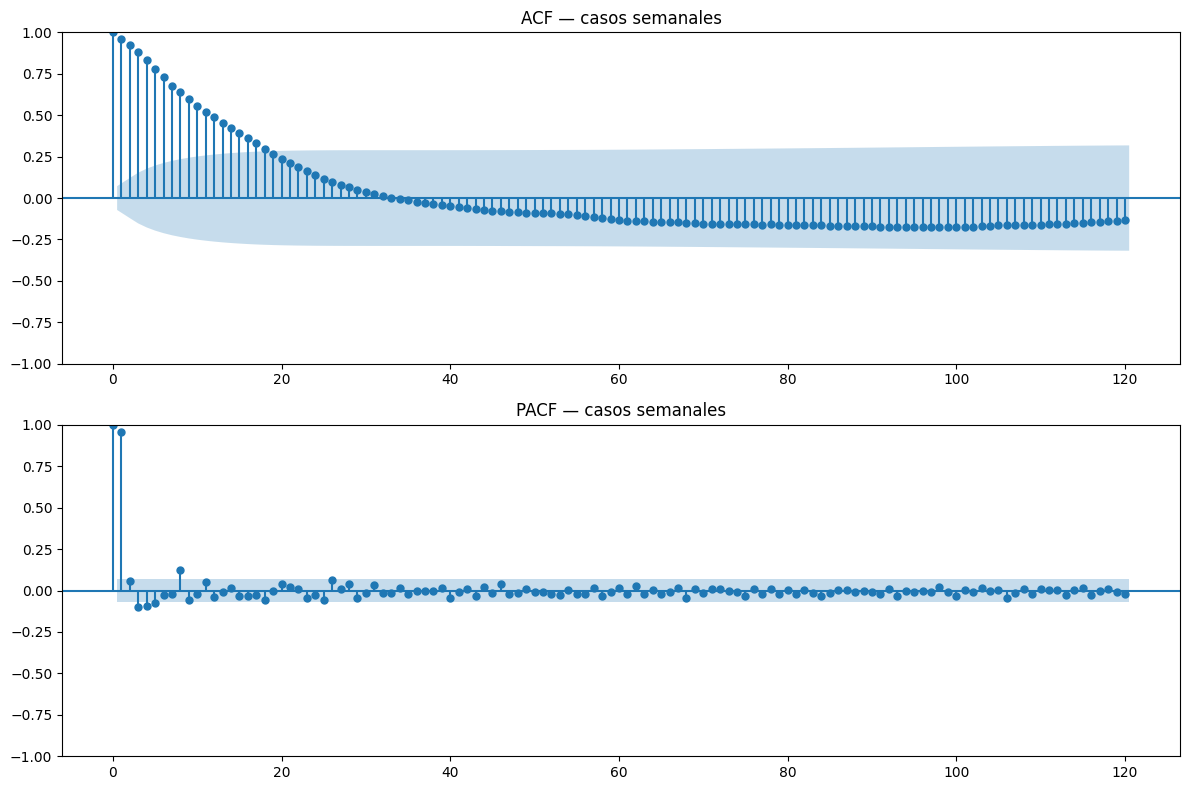

In [ ]:
# Gráficas ACF y PACF
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(serie, lags=MAX_LAG, ax=axes[0])
axes[0].set_title('ACF — casos semanales')
plot_pacf(serie, lags=MAX_LAG, ax=axes[1], method='ywm')
axes[1].set_title('PACF — casos semanales')
plt.tight_layout()
plt.show()

In [ ]:
# Ljung-Box en múltiples horizontes
lags_lb = [4, 8, 13, 26, 52, 78, 104]
ljung = acorr_ljungbox(serie, lags=lags_lb, return_df=True)
ljung['rechaza_ruido_blanco_5pct'] = ljung['lb_pvalue'] < 0.05
display(ljung)

,lb_stat,lb_pvalue,rechaza_ruido_blanco_5pct
4,"2,419.9382",0.0000,True
8,"3,935.6491",0.0000,True
13,"4,979.5318",0.0000,True
26,"5,694.9858",0.0000,True
52,"5,771.4257",0.0000,True
78,"6,191.0136",0.0000,True
104,"6,827.9755",0.0000,True


### Conclusión sobre Ljung-Box
La prueba Ljung-Box rechaza la hipótesis de ruido blanco en todos los horizontes evaluados, desde 4 hasta 104 semanas, con p-valores prácticamente cero. Por tanto, la serie contiene dependencia temporal explotable y no debe modelarse como observaciones independientes. Este resultado justifica avanzar hacia modelos con memoria, rezagos y posibles componentes estacionales o cíclicos.


### Lectura para modelos futuros

- Una ACF con decaimiento lento indica fuerte persistencia: el nivel de casos de una semana se parece al de semanas cercanas.
- Si aparecen lags cercanos a 52, se revisa estacionalidad anual; si los máximos de poder están en períodos multi-anuales, se interpreta como ciclos epidémicos.
- La PACF en lags bajos sugiere que modelos AR o SARIMA podrían requerir términos autoregresivos en fases posteriores.
- Si Ljung-Box rechaza ruido blanco, hay información temporal explotable por modelos de pronóstico.

## 9. Modelos baseline y validación temporal

Se implementan los cuatro baseline obligatorios:

1. **Naive:** predice la última observación disponible.
2. **Seasonal Naive:** predice el valor del mismo período estacional anterior.
3. **SMA:** media móvil simple con ventana configurable.
4. **Drift:** extrapola una tendencia lineal entre el primer y último valor del entrenamiento.

### División entrenamiento/prueba
Se reserva el último año aproximadamente (**52 semanas**) como prueba. Esta elección es natural para datos semanales porque permite evaluar al menos un ciclo anual completo y mantiene el orden temporal sin mezclar futuro con pasado.

In [ ]:
# ============================================================
# 11. BASELINES EVALUADOS CON HOLDOUT TEMPORAL
# ============================================================
def split_temporal(s: pd.Series, h: int = 52):
    return s.iloc[:-h], s.iloc[-h:]

def inv_transform(y, transform):
    y = np.asarray(y, dtype=float)
    if transform == 'original':
        return y
    if transform == 'log1p':
        return np.expm1(y)
    if transform == 'sqrt':
        return np.square(y)
    raise ValueError(transform)

def apply_transform(y, transform):
    if transform == 'original':
        return y.astype(float)
    if transform == 'log1p':
        return np.log1p(y.astype(float))
    if transform == 'sqrt':
        return np.sqrt(y.astype(float))
    raise ValueError(transform)

def forecast_naive(train: pd.Series, h: int) -> np.ndarray:
    return np.repeat(train.iloc[-1], h)

def forecast_seasonal_naive(train: pd.Series, h: int, season_length: int) -> np.ndarray:
    history = list(train.values)
    preds = []
    for _ in range(h):
        if len(history) >= season_length:
            pred = history[-season_length]
        else:
            pred = history[-1]
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

def forecast_sma(train: pd.Series, h: int, window: int = 4) -> np.ndarray:
    history = list(train.values)
    preds = []
    for _ in range(h):
        pred = np.mean(history[-window:])
        preds.append(pred)
        history.append(pred)
    return np.array(preds)

def forecast_drift(train: pd.Series, h: int) -> np.ndarray:
    n = len(train)
    slope = (train.iloc[-1] - train.iloc[0]) / (n - 1)
    return np.array([train.iloc[-1] + step * slope for step in range(1, h + 1)])

def mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluar_predicciones(y_true, y_pred) -> dict:
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0)  # conteos no negativos
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape(y_true, y_pred)
    }

def evaluar_baselines(s: pd.Series, h: int, season_length: int, sma_windows=(4, 13, 26), transforms=('original','log1p','sqrt')):
    train_original, test_original = split_temporal(s, h)
    rows = []
    predictions = {}
    for transform in transforms:
        train_t = pd.Series(apply_transform(train_original, transform), index=train_original.index)
        model_preds = {
            'Naive': forecast_naive(train_t, h),
            f'SeasonalNaive_{season_length}': forecast_seasonal_naive(train_t, h, season_length),
            'Drift': forecast_drift(train_t, h)
        }
        for w in sma_windows:
            model_preds[f'SMA_{w}'] = forecast_sma(train_t, h, window=w)
        
        for model_name, pred_t in model_preds.items():
            pred = inv_transform(pred_t, transform)
            pred = np.maximum(pred, 0)
            metrics = evaluar_predicciones(test_original, pred)
            row = {'transformacion': transform, 'modelo': model_name, **metrics}
            rows.append(row)
            predictions[(transform, model_name)] = pd.Series(pred, index=test_original.index, name=f'{model_name}_{transform}')
    return pd.DataFrame(rows).sort_values(['RMSE','MAE']), predictions, train_original, test_original

H = 52
metrics_table, baseline_predictions, train, test = evaluar_baselines(
    serie, h=H, season_length=SEASONAL_PERIOD, sma_windows=(4, 13, 26), transforms=('original','log1p','sqrt')
)

display(metrics_table)
print('Mejor combinación por RMSE:')
display(metrics_table.head(1))

,transformacion,modelo,MAE,RMSE,MAPE
8,log1p,Drift,155.7226,197.2927,400.1974
14,sqrt,Drift,155.9473,198.1899,386.5607
2,original,Drift,156.0937,198.7395,378.5650
0,original,Naive,156.4615,200.0515,360.2790
6,log1p,Naive,156.4615,200.0515,360.2790
12,sqrt,Naive,156.4615,200.0515,360.2790
3,original,SMA_4,160.0313,205.4585,322.0483
15,sqrt,SMA_4,160.1433,205.6182,320.9578
9,log1p,SMA_4,160.2522,205.7739,319.8961
4,original,SMA_13,164.6830,212.0462,278.2150


Mejor combinación por RMSE:


,transformacion,modelo,MAE,RMSE,MAPE
8,log1p,Drift,155.7226,197.2927,400.1974


### Conclusión de la sección 9
En el holdout final, el mejor baseline por RMSE es `Drift` sobre `log1p`, con MAE de 155.72 y RMSE de 197.29. Sin embargo, las métricas son altas frente a la media histórica semanal, lo que indica que el último año de prueba incluye cambios difíciles para modelos simples. Seasonal Naive no lidera el desempeño, consistente con la estacionalidad anual débil observada en la descomposición.


In [ ]:
# Visualización del mejor baseline contra el conjunto de prueba
best = metrics_table.iloc[0]
best_key = (best['transformacion'], best['modelo'])
best_pred = baseline_predictions[best_key]

fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index[-156:], y=train.iloc[-156:], name='Entrenamiento (últimas 156 semanas)', mode='lines'))
fig.add_trace(go.Scatter(x=test.index, y=test, name='Prueba real', mode='lines+markers'))
fig.add_trace(go.Scatter(x=best_pred.index, y=best_pred, name=f"Mejor baseline: {best['modelo']} + {best['transformacion']}", mode='lines+markers'))
fig.update_layout(template='plotly_white', title='Mejor modelo baseline vs observaciones reales', xaxis_title='Semana', yaxis_title='Casos')
fig.show()

In [ ]:
# Comparación visual de todos los modelos en escala original para la mejor transformación de cada modelo
top_by_model = metrics_table.sort_values('RMSE').groupby('modelo').head(1)
fig = go.Figure()
fig.add_trace(go.Scatter(x=test.index, y=test, name='Real', mode='lines+markers'))
for _, row in top_by_model.iterrows():
    pred = baseline_predictions[(row['transformacion'], row['modelo'])]
    fig.add_trace(go.Scatter(x=pred.index, y=pred, name=f"{row['modelo']} ({row['transformacion']})", mode='lines'))
fig.update_layout(template='plotly_white', title='Comparación de baselines en el período de prueba', xaxis_title='Semana', yaxis_title='Casos')
fig.show()

### Lectura visual de los baselines
La comparación gráfica debe interpretarse como una línea mínima de desempeño, no como un modelo final. Los baselines capturan continuidad o tendencia simple, pero tienen poca capacidad para anticipar saltos bruscos asociados a brotes. Cualquier modelo posterior debe superar estas métricas y, además, mejorar la respuesta ante cambios rápidos de nivel.


## 10. Validación robusta adicional: rolling origin cross-validation

Además del holdout final, se incluye una validación temporal con origen móvil. Esta parte no reemplaza la evaluación principal, pero ayuda a evitar conclusiones dependientes de un único año de prueba, especialmente en dengue, donde los brotes pueden concentrarse en períodos específicos.

In [ ]:
# ============================================================
# 12. CROSS-VALIDATION TEMPORAL DE BASELINES
# ============================================================
def rolling_origin_splits(s: pd.Series, initial_train: int, horizon: int, step: int):
    start = initial_train
    while start + horizon <= len(s):
        yield s.iloc[:start], s.iloc[start:start+horizon]
        start += step

def evaluar_baseline_cv(s: pd.Series, model_name: str, transform: str, season_length: int, horizon: int = 26, initial_train: int = 260, step: int = 26, sma_window: int = 13):
    rows = []
    for fold, (train_o, test_o) in enumerate(rolling_origin_splits(s, initial_train, horizon, step), start=1):
        train_t = pd.Series(apply_transform(train_o, transform), index=train_o.index)
        if model_name == 'Naive':
            pred_t = forecast_naive(train_t, len(test_o))
        elif model_name == f'SeasonalNaive_{season_length}':
            pred_t = forecast_seasonal_naive(train_t, len(test_o), season_length)
        elif model_name == 'Drift':
            pred_t = forecast_drift(train_t, len(test_o))
        elif model_name.startswith('SMA'):
            pred_t = forecast_sma(train_t, len(test_o), sma_window)
        else:
            raise ValueError(model_name)
        pred = np.maximum(inv_transform(pred_t, transform), 0)
        metrics = evaluar_predicciones(test_o, pred)
        rows.append({'fold': fold, 'inicio_test': test_o.index.min(), 'fin_test': test_o.index.max(),
                     'modelo': model_name, 'transformacion': transform, **metrics})
    return pd.DataFrame(rows)

# Se evalúan las mejores 5 combinaciones del holdout para no sobrecargar el notebook.
cv_frames = []
for _, row in metrics_table.head(5).iterrows():
    sma_window = 13
    if row['modelo'].startswith('SMA_'):
        sma_window = int(row['modelo'].split('_')[1])
    cv_frames.append(evaluar_baseline_cv(
        serie, row['modelo'], row['transformacion'], SEASONAL_PERIOD,
        horizon=26, initial_train=260, step=26, sma_window=sma_window
    ))

cv_results = pd.concat(cv_frames, ignore_index=True)
cv_summary = cv_results.groupby(['modelo','transformacion'])[['MAE','RMSE','MAPE']].agg(['mean','std']).sort_values(('RMSE','mean'))
display(cv_results.head())
display(cv_summary)

,fold,inicio_test,fin_test,modelo,transformacion,MAE,RMSE,MAPE
0,1,2014-12-28,2015-06-21,Drift,log1p,16.9374,22.0505,17.7631
1,2,2015-06-28,2015-12-20,Drift,log1p,20.2423,24.5494,25.1922
2,3,2015-12-27,2016-06-19,Drift,log1p,96.1630,119.8873,36.0648
3,4,2016-06-26,2016-12-18,Drift,log1p,127.6249,134.8647,378.5100
4,5,2016-12-25,2017-06-18,Drift,log1p,14.6590,15.8921,105.1379


MAE            RMSE            MAPE         
                         mean     std    mean     std    mean      std
modelo transformacion                                                 
Drift  original       42.8883 53.5391 50.0117 60.5843 90.1042 106.2250
       sqrt           42.8729 53.4830 50.0369 60.5280 90.8537 108.0926
Naive  log1p          43.0171 53.8329 50.0447 60.8550 88.3880 102.4019
       original       43.0171 53.8329 50.0447 60.8550 88.3880 102.4019
Drift  log1p          42.9205 53.5380 50.1898 60.5931 92.4206 112.1066

### Conclusión de la sección 10
La validación rolling-origin muestra que el desempeño cambia mucho según el periodo evaluado. En algunos folds el error es bajo, pero aumenta con fuerza durante fases de brote o transición, como se observa en RMSE altos y desviaciones estándar grandes. En promedio, `Drift` y `Naive` quedan muy cercanos, lo que confirma que los baselines son útiles como referencia, pero insuficientes para describir completamente la dinámica epidémica.


## 11. Conclusiones técnicas de Fase 1

1. **Calidad de datos:** la serie semanal queda regular entre el 3 de enero de 2010 y el 31 de marzo de 2024, con 744 observaciones, 61,933 casos agregados y cero semanas faltantes en el calendario. Las 3 semanas con cero casos se conservan porque son valores válidos para una serie de conteos.
2. **Valores extremos:** se detectan 57 outliers por IQR y 57 por MAD. Los picos se concentran en semanas asociadas a brotes, especialmente en 2010, 2020 y 2023; por tanto, se mantienen como información epidemiológica relevante.
3. **Estructura temporal:** la serie presenta alta dispersión, con media de 83.24, mediana de 51.00, desviación estándar de 97.33 y coeficiente de variación de 1.17. La asimetría positiva y la curtosis elevada muestran que el comportamiento está dominado por periodos de baja/moderada incidencia interrumpidos por brotes intensos.
4. **Estacionalidad y ciclos:** aunque el período operativo seleccionado es 52 semanas por criterio epidemiológico y utilidad práctica, el periodograma destaca ciclos multi-anuales cercanos a 186 y 248 semanas. La estacionalidad anual existe como referencia, pero no es el componente dominante.
5. **Descomposición:** la fuerza de tendencia supera claramente a la fuerza estacional. En `log1p`, la tendencia alcanza 0.6746 y la estacionalidad solo 0.0282, lo que indica que los cambios de régimen y los ciclos de brote explican más que un patrón anual fijo.
6. **Transformaciones:** ADF y KPSS entregan criterio conjunto favorable para las transformaciones evaluadas. Para modelado posterior, `log1p(casos)` es especialmente conveniente porque admite ceros, estabiliza varianza y reduce la influencia de valores extremos sin perder recuperabilidad a escala original.
7. **Autocorrelación:** la ACF de lag 1 es 0.9576 y el decaimiento es lento, lo que confirma fuerte persistencia semanal. Ljung-Box rechaza ruido blanco en todos los horizontes evaluados, así que hay dependencia temporal real que modelos con memoria deberían aprovechar.
8. **Baseline:** en holdout, el mejor resultado por RMSE es `Drift` con transformación `log1p` (MAE = 155.72, RMSE = 197.29, MAPE = 400.20%). El error sigue siendo alto, lo que evidencia que los baselines simples no anticipan bien brotes o cambios bruscos.
9. **Validación robusta:** rolling-origin confirma que el desempeño depende mucho del periodo de prueba. Los errores crecen durante fases de transición o brote, por lo que el benchmark debe evaluarse con varias ventanas y no con un único corte temporal.

### Recomendación para fases posteriores
Usar este resultado como benchmark y avanzar en dos rutas:  
- **Ruta estadística:** ARIMA/SARIMA o SARIMAX sobre `log1p(casos)`, revisando órdenes con ACF/PACF y validación rolling-origin.  
- **Ruta ML/IA:** modelos supervisados con rezagos, medias móviles, variables calendario y, si están disponibles, covariables climáticas como precipitación, temperatura y humedad.


In [ ]:
# Resumen ejecutivo automático para pegar en el informe
best = metrics_table.iloc[0]
summary = f'''
RESUMEN EJECUTIVO
-----------------
Dataset: {len(raw):,} registros individuales de dengue.
Rango temporal: {raw['fec_not'].min().date()} a {raw['fec_not'].max().date()}.
Serie modelada: casos semanales agregados, {len(serie):,} observaciones.
Total casos agregados: {int(serie.sum()):,}.
Media semanal: {serie.mean():.2f}; desviación estándar: {serie.std():.2f}; CV: {serie.std()/serie.mean():.2f}.
Asimetría: {stats.skew(serie, bias=False):.2f}; curtosis exceso: {stats.kurtosis(serie, fisher=True, bias=False):.2f}.
Periodo estacional operativo seleccionado: {SEASONAL_PERIOD} semanas.
Mejor baseline holdout: {best['modelo']} con transformación {best['transformacion']}.
MAE: {best['MAE']:.2f}; RMSE: {best['RMSE']:.2f}; MAPE: {best['MAPE']:.2f}%.
'''
print(summary)


RESUMEN EJECUTIVO
-----------------
Dataset: 61,933 registros individuales de dengue.
Rango temporal: 2010-01-03 a 2024-03-29.
Serie modelada: casos semanales agregados, 744 observaciones.
Total casos agregados: 61,933.
Media semanal: 83.24; desviación estándar: 97.33; CV: 1.17.
Asimetría: 2.06; curtosis exceso: 4.55.
Periodo estacional operativo seleccionado: 52 semanas.
Mejor baseline holdout: Drift con transformación log1p.
MAE: 155.72; RMSE: 197.29; MAPE: 400.20%.

